# SECOM dataset ML Project
---

### Loading in the SECOM dataset

In [254]:
# Imports
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import mutual_info_classif
from sklearn import set_config
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from umap import UMAP

In [163]:
set_config(transform_output="pandas")

In [164]:
# Pulling in the SECOM data and loading data into feature and label dataframes
secom = fetch_ucirepo(id=179)
df = pd.DataFrame(secom.data.original)
X = df.drop(columns=["class", "timestamp"])
y = df["class"]

print(X.shape)
print(y.shape)

(1567, 590)
(1567,)


---

### Exploratory Data Analysis (EDA)

In [165]:
# checking data types of features
X.dtypes.value_counts()

float64    590
Name: count, dtype: int64

In [166]:
# checking null counts and null percentage of features
feature_summary = pd.DataFrame({
    "null_counts": X.isna().sum(),
    "null_pct": round(X.isna().mean()*100, 2)
}).sort_values("null_pct", ascending=False)

print(feature_summary.head(50))

               null_counts  null_pct
Attribute 293         1429     91.19
Attribute 294         1429     91.19
Attribute 159         1429     91.19
Attribute 158         1429     91.19
Attribute 493         1341     85.58
Attribute 86          1341     85.58
Attribute 359         1341     85.58
Attribute 221         1341     85.58
Attribute 245         1018     64.96
Attribute 518         1018     64.96
Attribute 110         1018     64.96
Attribute 247         1018     64.96
Attribute 384         1018     64.96
Attribute 383         1018     64.96
Attribute 385         1018     64.96
Attribute 246         1018     64.96
Attribute 112         1018     64.96
Attribute 111         1018     64.96
Attribute 517         1018     64.96
Attribute 519         1018     64.96
Attribute 581          949     60.56
Attribute 579          949     60.56
Attribute 580          949     60.56
Attribute 582          949     60.56
Attribute 74           794     50.67
Attribute 346          794     50.67
A

In [167]:
# checking class balance and null counts
label_summary = pd.DataFrame({
    "counts": y.value_counts(),
    "null_counts": y.isna().sum(),
    "pct": round(y.value_counts()/len(y)*100, 2),    
})

print(label_summary)

       counts  null_counts    pct
class                            
-1       1463            0  93.36
 1        104            0   6.64


In [168]:
y = y.replace(-1, 0)

---

In [169]:
# filtering out features with null percentage above threshold
threshold = 90 # null pct threshold

null_cols = X.columns[X.isna().mean()*100 > threshold]
X_filtered = X.drop(columns=null_cols)
X_filtered.shape

(1567, 586)

In [170]:
# Fill remaining NaN values with median
X_filtered = SimpleImputer(strategy='median').fit_transform(X_filtered)
X_filtered.isna().sum().sort_values(ascending=False).head()

Attribute 1    0
Attribute 2    0
Attribute 3    0
Attribute 4    0
Attribute 5    0
dtype: int64

In [171]:
# Remove constant variance terms
zero_var_cols = X_filtered.columns[X_filtered.var() == 0]
X_filtered = X_filtered.drop(columns=zero_var_cols)
X_filtered.shape

(1567, 470)

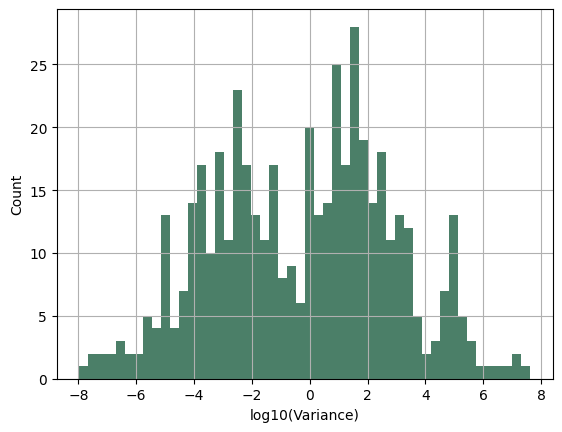

In [172]:
# Checking variance threshold to see if we have an obvious cutoff point
variances = X_filtered.var()

plt.hist(np.log10(variances), bins=50, color='#4B7F68')
plt.xlabel("log10(Variance)")
plt.ylabel("Count")
plt.grid()
plt.show()

In [173]:
# running a correlation analysis to identify highly correlated features
corr = X_filtered.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
pairs = upper.stack().reset_index()
pairs.columns = ["feature_1", "feature_2", "corr"]
pairs = pairs.sort_values(
    "corr",
    ascending=False
)

print(pairs.head(50))

            feature_1      feature_2      corr
32344    Attribute 75  Attribute 479  1.000000
133298  Attribute 343  Attribute 348  1.000000
89118   Attribute 210  Attribute 348  1.000000
89113   Attribute 210  Attribute 343  1.000000
89214   Attribute 210  Attribute 479  1.000000
32243    Attribute 75  Attribute 343  1.000000
32248    Attribute 75  Attribute 348  1.000000
32149    Attribute 75  Attribute 210  1.000000
135744  Attribute 348  Attribute 479  1.000000
87609   Attribute 207  Attribute 210  1.000000
87708   Attribute 207  Attribute 348  1.000000
87804   Attribute 207  Attribute 479  1.000000
32146    Attribute 75  Attribute 207  1.000000
87703   Attribute 207  Attribute 343  1.000000
133394  Attribute 343  Attribute 479  1.000000
15074    Attribute 35   Attribute 37  1.000000
62740   Attribute 141  Attribute 276  1.000000
75833   Attribute 173  Attribute 175  1.000000
121520  Attribute 308  Attribute 310  0.999999
67450   Attribute 153  Attribute 288  0.999997
99011   Attri

___

### Before moving any further with feature selection, looking at unsupervised dimensionality reduction techniques: beginning with PCA

In [174]:
# Running PCA
X_scaled = StandardScaler().fit_transform(X_filtered)
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

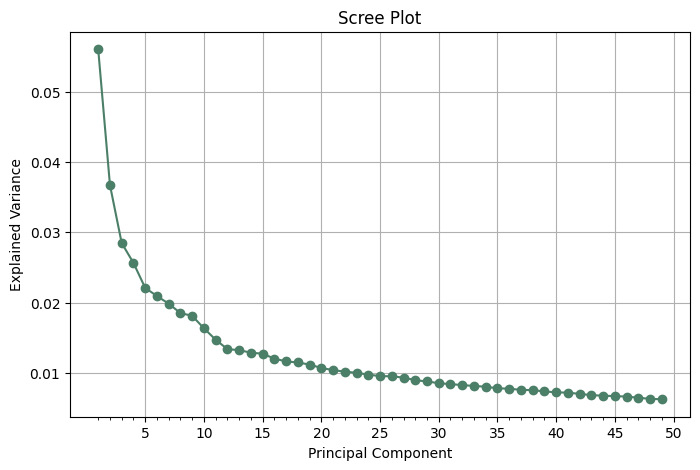

In [213]:
# Plotting the Scree plot
plt.figure(figsize=(8,5))
plt.plot(range(1, 50), pca.explained_variance_ratio_[:49], color='#4B7F68', marker='o')
plt.xlabel("Principal Component")
plt.xticks(ticks=range(5, 51, 5))
plt.xticks(ticks=range(1, 50), minor=True)
plt.ylabel("Explained Variance")
plt.title("Scree Plot")
plt.grid(True)
plt.show()

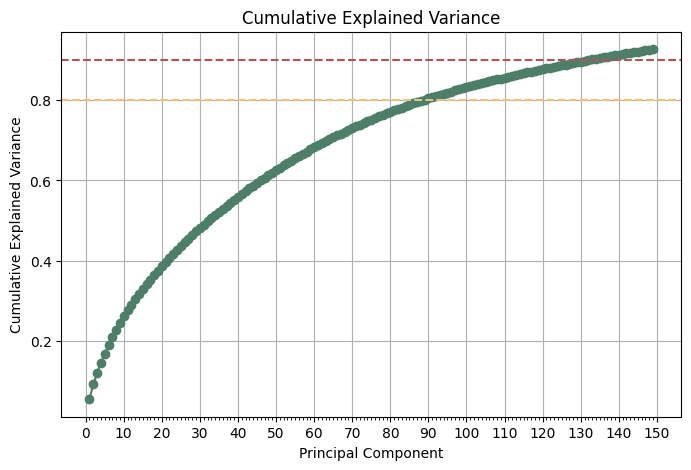

In [215]:
# Plotting cumulative explained variance
cum_var = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(8,5))
plt.plot(range(1, 150), cum_var[:149], color='#4B7F68', marker='o')
plt.xlabel("Principal Component")
plt.xticks(ticks=range(0, 151, 10))
plt.xticks(ticks=range(1, 150), minor=True)
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.grid(True)
plt.axhline(0.8, ls='--', color = '#EDC276')
plt.axhline(0.9, ls='--', color = '#B15455')
plt.show()

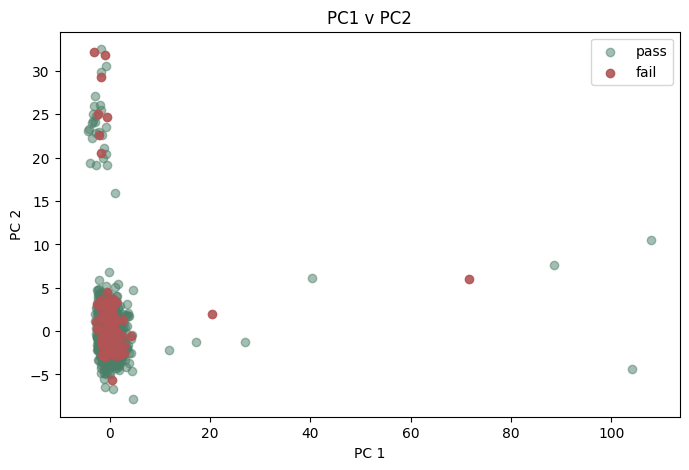

In [212]:
# Plotting PC1 v PC2
plt.figure(figsize=(8,5))
plt.scatter(X_pca.loc[y==0, "pca0"], X_pca.loc[y==0, "pca1"], alpha=0.5, label="pass", color='#4B7F68')
plt.scatter(X_pca.loc[y==1, "pca0"], X_pca.loc[y==1, "pca1"], alpha=0.9, label="fail", color='#B15455')
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.title("PC1 v PC2")
plt.legend()
plt.show()

In [ ]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=X_scaled.columns,
    columns= [f"PC{i+1}" for i in range(pca.n_components_)]
)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,PC21,PC22,PC23,PC24,PC25,PC26,PC27,PC28,PC29,PC30,PC31,PC32,PC33,PC34,PC35,PC36,PC37,PC38,PC39,PC40,...,PC431,PC432,PC433,PC434,PC435,PC436,PC437,PC438,PC439,PC440,PC441,PC442,PC443,PC444,PC445,PC446,PC447,PC448,PC449,PC450,PC451,PC452,PC453,PC454,PC455,PC456,PC457,PC458,PC459,PC460,PC461,PC462,PC463,PC464,PC465,PC466,PC467,PC468,PC469,PC470
Attribute 1,-0.006069,-0.024874,-0.009830,0.010372,0.011443,-0.014715,0.008769,-0.009524,0.016690,-0.005901,0.004517,0.008717,-0.014699,-0.017171,-0.013240,0.050084,-0.033918,0.011353,-0.041381,-0.005465,-0.056502,0.013343,-0.008976,-0.012031,0.023861,-0.025139,0.006849,-0.000542,-0.028016,-0.061611,0.010064,-0.035829,0.001625,0.005775,-0.031308,-0.011261,-0.026475,0.036684,-0.019679,-0.017562,...,0.000580,-0.000314,-0.001606,-0.000872,-0.000769,0.001302,-0.000665,-0.001352,0.000852,-0.000365,9.676915e-07,0.000161,0.000355,-0.000143,0.000245,-0.000544,-0.000541,-0.000063,0.000070,0.000121,0.000429,-0.000091,-0.000499,-0.000012,0.000297,0.000250,-0.000224,-0.000006,-0.000151,-0.000011,-0.000006,-0.000018,0.000059,0.000002,1.175264e-06,3.500701e-16,0.000000e+00,0.000000e+00,0.000000e+00,-0.000000e+00
Attribute 2,-0.000007,0.012917,-0.002995,0.006529,-0.012918,0.005857,-0.002862,0.001266,0.016775,-0.000651,-0.000104,0.007610,-0.003347,0.019788,0.006515,-0.034200,0.013044,-0.025381,0.031048,0.003678,0.033665,0.007340,-0.002515,-0.020221,-0.005523,0.015936,-0.012791,-0.052904,0.044315,-0.006671,-0.019806,0.021653,0.005964,-0.005579,0.006132,-0.007156,-0.004118,-0.045182,0.027848,-0.043053,...,0.002363,-0.000889,-0.000392,0.000305,0.000037,0.000814,-0.000603,-0.000641,0.001209,-0.000115,3.552376e-04,0.000045,0.000232,-0.000367,-0.000146,0.000066,0.000656,0.000236,-0.000190,0.000087,0.000165,0.000484,0.000220,-0.000020,-0.000125,-0.000013,0.000050,0.000031,0.000010,0.000093,-0.000016,-0.000037,-0.000033,-0.000005,5.787498e-07,-6.957692e-17,-4.485665e-18,-1.078102e-16,-2.798581e-17,-3.763573e-17
Attribute 3,-0.003859,0.008983,-0.008271,0.012990,-0.001323,-0.000530,-0.004506,0.014610,-0.011732,-0.053535,0.052659,-0.007175,0.001456,-0.020142,0.025044,0.015455,-0.007537,0.043382,0.029725,-0.026740,-0.008594,-0.010850,-0.018873,0.011425,0.035577,-0.002809,0.022164,0.037081,-0.022593,0.021029,0.030112,0.026818,0.015487,-0.016560,-0.011381,0.014463,0.029401,-0.018099,-0.006079,0.017601,...,-0.003037,0.000636,0.000937,0.002095,0.001910,-0.001530,-0.001014,-0.001217,0.000022,-0.001607,5.945684e-05,0.002539,0.003627,0.000591,0.000468,0.000122,-0.000196,0.000367,0.000657,-0.000011,-0.000184,-0.000294,-0.000368,-0.000098,0.000340,-0.000316,0.000021,-0.000018,-0.000073,-0.000094,-0.000018,-0.000061,0.000047,0.000246,3.680865e-07,-2.044441e-16,-8.630615e-17,-2.673317e-17,-6.831491e-17,1.121553e-17
Attribute 4,0.002235,-0.032994,-0.025333,0.031297,-0.007456,-0.020390,0.022083,-0.024020,0.019641,-0.031180,-0.035227,-0.040418,-0.009675,-0.044426,-0.025450,0.062235,0.012328,0.037342,0.018009,-0.064816,0.017153,0.057269,0.006861,0.040933,0.055513,0.002774,0.030960,-0.065196,-0.120382,0.034930,-0.030081,0.038187,0.037644,0.028895,-0.002642,-0.056281,0.036665,-0.070113,-0.017274,-0.017506,...,-0.000163,-0.001615,0.001376,-0.001444,0.000603,0.000743,-0.000053,-0.001365,0.000297,-0.000420,8.216931e-04,0.000583,0.000623,0.000076,0.000037,-0.000182,-0.000125,-0.000182,0.000159,-0.000092,0.000278,-0.000463,-0.000158,0.000398,0.000036,0.000123,-0.000194,-0.000083,0.000041,-0.000049,-0.000010,-0.000006,0.000051,0.000027,-6.685524e-07,7.239086e-17,4.823062e-17,-1.814645e-17,-4.466147e-17,1.959056e-17
Attribute 5,0.000703,-0.008895,-0.021643,0.031448,-0.010447,0.005427,-0.010465,-0.005377,0.012387,-0.027507,0.240283,-0.067528,0.179916,0.034618,0.096950,-0.059422,0.010269,-0.048767,-0.039430,-0.031448,0.018150,0.022171,0.068220,-0.030685,-0.020750,0.014316,0.036939,0.064060,-0.051291,0.015026,-0.020342,0.030831,-0.040636,-0.017462,0.009

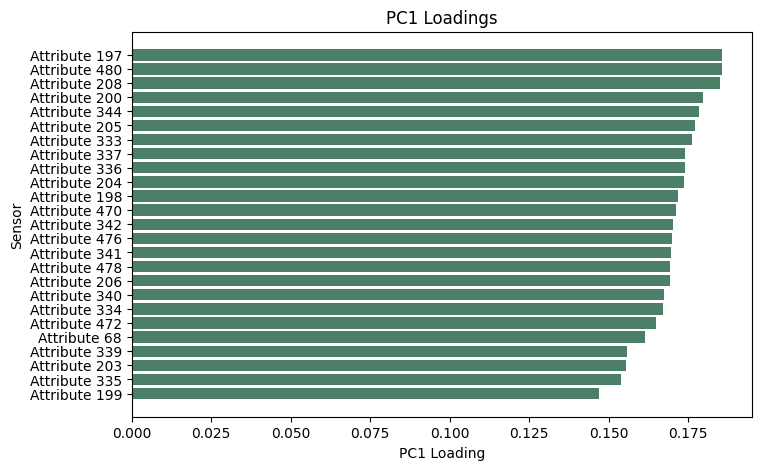

In [252]:
top_sorted = loadings["PC1"].abs().sort_values(ascending=False).head(25)
top_plot = top_sorted.sort_values()
plt.figure(figsize=(8,5))
plt.barh(top_plot.index, top_plot, color='#4B7F68')
plt.xlabel("PC1 Loading")
plt.ylabel("Sensor")
plt.title("PC1 Loadings")
plt.show()

#### Remarks: PCA does not show dominant lower dimensional modes to be xisting in the data.  Many PCs needed to explain 80% of the variance and loadings seem similar amongst sensors for PC1.

Next step: Check PLS latent variables if any signal can be teased out from the labels.

In [240]:
# PLS
pls = PLSRegression(n_components=2)
X_pls, y_pls = pls.fit_transform(X_scaled, y)
X_pls.columns = ["LV1", "LV2"]

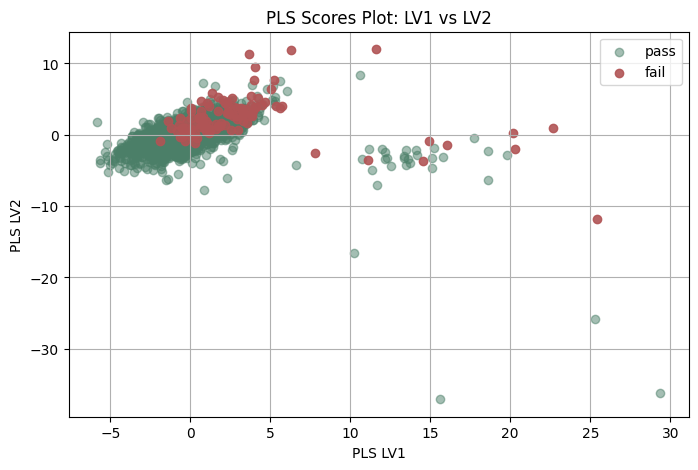

In [242]:
# PLS LV plots

plt.figure(figsize=(8,5))

plt.scatter(
    X_pls.loc[y == 0, "LV1"],
    X_pls.loc[y == 0, "LV2"],
    alpha=0.5,
    label="pass",
    color="#4B7F68"
)

plt.scatter(
    X_pls.loc[y == 1, "LV1"],
    X_pls.loc[y == 1, "LV2"],
    alpha=0.9,
    label="fail",
    color="#B15455"
)

plt.xlabel("PLS LV1")
plt.ylabel("PLS LV2")
plt.title("PLS Scores Plot: LV1 vs LV2")
plt.legend()
plt.grid(True)
plt.show()

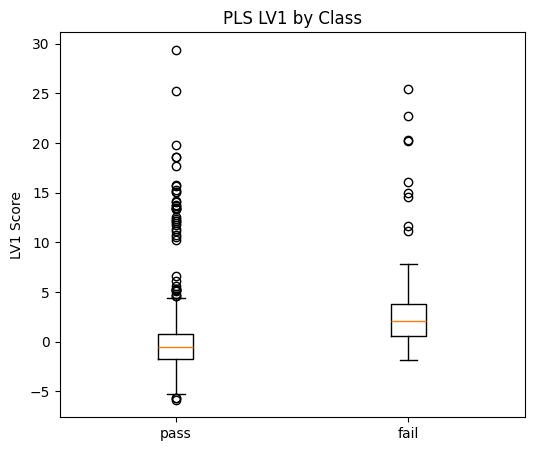

In [246]:
# LV1 vs y plot

plt.figure(figsize=(6,5))

plt.boxplot(
    [
        X_pls.loc[y==0, "LV1"],
        X_pls.loc[y==1, "LV1"]
    ],
    tick_labels=["pass", "fail"]
)

plt.ylabel("LV1 Score")
plt.title("PLS LV1 by Class")
plt.show()

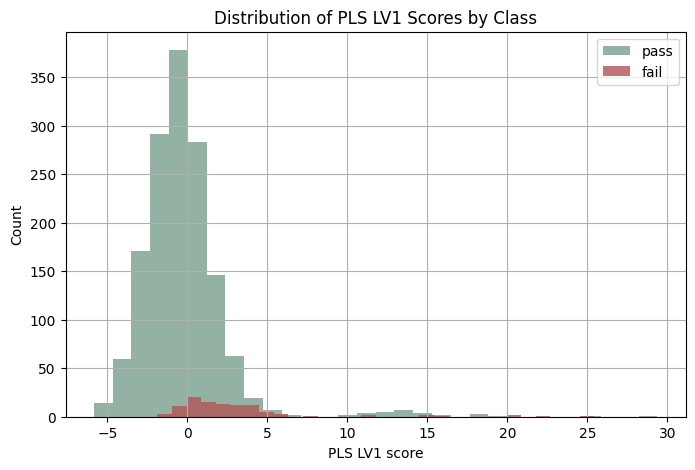

In [244]:
plt.figure(figsize=(8,5))

plt.hist(
    X_pls.loc[y == 0, "LV1"],
    bins=30,
    alpha=0.6,
    label="pass",
    color="#4B7F68"
)

plt.hist(
    X_pls.loc[y == 1, "LV1"],
    bins=30,
    alpha=0.8,
    label="fail",
    color="#B15455"
)

plt.xlabel("PLS LV1 score")
plt.ylabel("Count")
plt.title("Distribution of PLS LV1 Scores by Class")
plt.legend()
plt.grid(True)
plt.show()

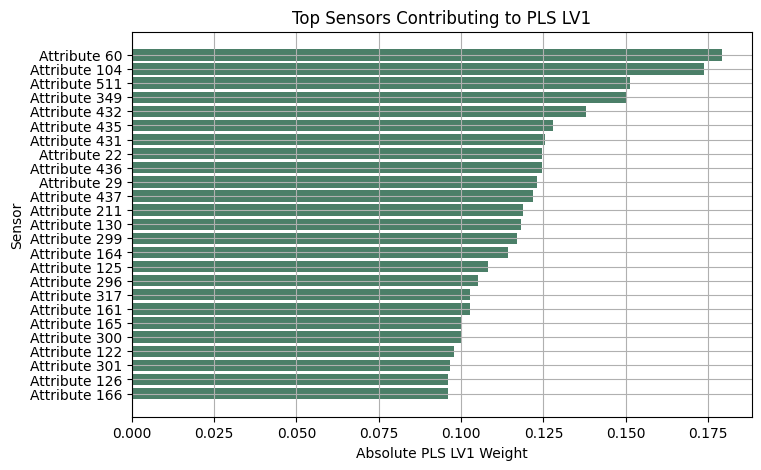

In [253]:
weights = pd.DataFrame(
    pls.x_weights_,
    index=X_scaled.columns,
    columns=["LV1", "LV2"]
)

top = weights["LV1"].abs().sort_values(ascending=False).head(25)

plt.figure(figsize=(8,5))
plt.barh(
    top.sort_values().index,
    top.sort_values(),
    color="#4B7F68"
)
plt.xlabel("Absolute PLS LV1 Weight")
plt.ylabel("Sensor")
plt.title("Top Sensors Contributing to PLS LV1")
plt.grid(True)
plt.show()

#### Remarks: PLS is slightly better than PCA in showing class separation.  We can see the boxplots of LV1 by class have some delta in medians and the histogram plot shows a shifted LV1 score on passes v fails

Next step: run UMAP to visualize potential non-linear patterns

___

In [62]:
# identifying columns to drop that are correlated more than 95%
to_drop = [
    col
    for col in upper.columns
    if any(upper[col] > 0.95)
]

print(f"Columns to drop: {len(to_drop)}")

Columns to drop: 186


In [ ]:
# examining the highly correlated feature pairs
high_corr = pairs[pairs["corr"] > 0.95]
high_corr.sort_values("corr", ascending=False).head(100)

In [ ]:
# removing the columns correlated above threshold from the dataset
X_uncorr = X_filtered.drop(columns=to_drop)
X_uncorr.shape

In [ ]:
# checking correlations with target
mi = mutual_info_classif(
    X_uncorr,
    y,
    random_state=42
)

mi = pd.Series(
    mi,
    index=X_uncorr.columns
)

mi.sort_values(
    ascending=False
).describe()

In [ ]:
# checking how many features have zero mutual info with target
zero_mi = mi.value_counts()
zero_mi

In [ ]:
# plotting histogram of log mi to see distribution
plt.hist(np.log10(mi[mi > 0]), bins=50, color='#4B7F68')
plt.xlabel("log10(mi)")
plt.ylabel("counts")

___

### Final Remarks
1. classes highly imbalanced
2. features highly correlated
3. No obvious variance cutoff after removing zero-variance features
4. Mutual information is not very high for any given sensor, will not use MI to exclude features

### Final Preprocessing Recommendation
1. Remove null features with > 90% nulls
2. Impute missing data with median
3. Remove zero-variance features
4. Drop columns with > 95% correlation

### Modeling Suggestions
1. Try logistic regression with L1 regularization and inspect feature coefficients
2. Try PLS-DA and check latent variables for key features
3. Run XGBoost and compare performance gains with the linear models

